In [1]:
# ---------------------------------
# PINN: Geostrophic flow
# ---------------------------------
import scipy.io
import numpy as np
import tensorflow as tf
import sys
import os
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()

sys.path.append(os.path.abspath(os.path.join(current_dir, '..')))
from model import GeostrophicPINN

2026-06-28 20:33:56.208269: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-28 20:33:56.221384: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782696836.237480   17196 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782696836.242297   17196 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-28 20:33:56.258602: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [7]:
# ---------------------------------
# Main 1: Train Taylor-Green Vortex
# ---------------------------------

if __name__ == "__main__": 
    DATA_PATH = '../Data/geostrophic_cyclone_data.mat'
    SAVE_DIR = 'Results/Ciclonic'
    os.makedirs(SAVE_DIR, exist_ok=True)
    RESULTS_PATH = os.path.join(SAVE_DIR, 'ciclonic_results.npz')
    
    # Hyperparameters configuration
    N_train = 5000
    layers = [3, 50, 50, 50, 50, 50, 50, 50, 50, 2]
    noise_level = 0.05  # 5% de ruido Gaussiano
    
    # Load simulation data
    data = scipy.io.loadmat(DATA_PATH)
    U_raw = data['U_star'] # (100, 100, 20, 2)
    P_raw = data['p_star'] # (100, 100, 20)
    t_star = data['t'].flatten()
    X_star_raw = data['X_star'] # (10000, 2)

    # Rearrange U to (10000, 2, 20)
    U_reshaped = U_raw.reshape(-1, 20, 2) 
    U_star = np.transpose(U_reshaped, (0, 2, 1))
    
    # Rearrange P to (10000, 20)
    P_star = P_raw.reshape(-1, 20)

    # Flatten for training
    N = 10000; T = 20
    x = np.tile(X_star_raw[:,0:1], (1,T)).flatten()[:,None]
    y = np.tile(X_star_raw[:,1:2], (1,T)).flatten()[:,None]
    t = np.tile(t_star, (1,N)).T.flatten()[:,None]
    u = U_star[:,0,:].flatten()[:,None]
    v = U_star[:,1,:].flatten()[:,None]
    p = P_star.flatten()[:,None]

    # Random selection of training points
    idx = np.random.choice(N*T, N_train, replace=False)
    x_train, y_train, t_train = x[idx], y[idx], t[idx]
    u_train, v_train, p_train = u[idx], v[idx], p[idx]

    # Gaussian Noise
    u_train = u_train + noise_level * np.std(u_train) * np.random.randn(*u_train.shape)
    v_train = v_train + noise_level * np.std(v_train) * np.random.randn(*v_train.shape)

    # Convert to TensorFlow tensors
    x_tf = tf.convert_to_tensor(x_train, dtype=tf.float32)
    y_tf = tf.convert_to_tensor(y_train, dtype=tf.float32)
    t_tf = tf.convert_to_tensor(t_train, dtype=tf.float32)
    u_tf = tf.convert_to_tensor(u_train, dtype=tf.float32)
    v_tf = tf.convert_to_tensor(v_train, dtype=tf.float32)
    p_tf = tf.convert_to_tensor(p_train, dtype=tf.float32)

    # Training
    model = GeostrophicPINN(layers, 
                            tf.constant([x.min(), y.min(), t.min()], dtype=tf.float32), 
                            tf.constant([x.max(), y.max(), t.max()], dtype=tf.float32))
    
    print("   >>> Phase 1: Data Fitting ...")
    model.train(x_tf, y_tf, t_tf, u_tf, v_tf, p_tf, epochs=3000, train_params=False, physics_weight=0.0)

    print("   >>> Phase 2: Physics Discovery ...")
    model.reset_optimizer()
    model.train(x_tf, y_tf, t_tf, u_tf, v_tf, p_tf, epochs=6000, train_params=True, physics_weight=1.0)
    
    # Save results to compressed .npz file
    u_pred, v_pred, p_pred, _, _ = model.net_NS(x_tf, y_tf, t_tf)
    
    np.savez(RESULTS_PATH, 
             u_pred=u_pred.numpy(), v_pred=v_pred.numpy(), p_pred=p_pred.numpy(), 
             lambda_1=model.lambda_1.numpy()[0], 
             lambda_2=model.lambda_2.numpy()[0],
             lambda_3=model.lambda_3.numpy()[0],
             x_train=x_train, y_train=y_train, snap=10,
             loss_total=np.array(model.loss_history['total']),
             loss_data=np.array(model.loss_history['data']),
             loss_phys=np.array(model.loss_history['phys']))
             
    print("Done!")

   >>> Fase 1: Ajuste de Datos (Physics OFF)...
It: 0 [PARAMS:OFF|PHYS:OFF], Loss: 1.349e-01, l1: 0.0, l2(Visc): 0.01000, l3(Cor): 0.5000, Time: 9.35s
It: 100 [PARAMS:OFF|PHYS:OFF], Loss: 2.478e-03, l1: 0.0, l2(Visc): 0.01000, l3(Cor): 0.5000, Time: 71.57s
It: 200 [PARAMS:OFF|PHYS:OFF], Loss: 4.860e-04, l1: 0.0, l2(Visc): 0.01000, l3(Cor): 0.5000, Time: 69.38s
It: 300 [PARAMS:OFF|PHYS:OFF], Loss: 3.808e-04, l1: 0.0, l2(Visc): 0.01000, l3(Cor): 0.5000, Time: 69.62s
It: 400 [PARAMS:OFF|PHYS:OFF], Loss: 3.184e-04, l1: 0.0, l2(Visc): 0.01000, l3(Cor): 0.5000, Time: 69.16s
It: 500 [PARAMS:OFF|PHYS:OFF], Loss: 3.312e-04, l1: 0.0, l2(Visc): 0.01000, l3(Cor): 0.5000, Time: 69.29s
It: 600 [PARAMS:OFF|PHYS:OFF], Loss: 2.676e-04, l1: 0.0, l2(Visc): 0.01000, l3(Cor): 0.5000, Time: 69.40s
It: 700 [PARAMS:OFF|PHYS:OFF], Loss: 2.940e-04, l1: 0.0, l2(Visc): 0.01000, l3(Cor): 0.5000, Time: 69.54s
It: 800 [PARAMS:OFF|PHYS:OFF], Loss: 2.337e-04, l1: 0.0, l2(Visc): 0.01000, l3(Cor): 0.5000, Time: 69.15s
I

In [2]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import MaxNLocator  
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.interpolate import griddata
import os
from scipy.interpolate import griddata

In [3]:
# Visual setup
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 16
})

def plot_3d_surface(X, Y, Z, z_label, x_train, y_train, fig_size=(9, 8), plot_title=None):
    fig = plt.figure(figsize=fig_size)
    ax = fig.add_subplot(1, 1, 1, projection='3d')
    
    surf = ax.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.9, edgecolor='none')

    if plot_title:
        ax.set_title(plot_title, fontsize=20, pad=15)
    
    # Axis configuration
    z_min = np.nanmin(Z) - 0.2
    ax.set_zlim(z_min, np.nanmax(Z))
    ax.scatter(x_train, y_train, np.full_like(x_train, z_min), c='k', marker='.', s=1, alpha=0.2)
    
    # Z-axis tick reduction to prevent saturation
    ax.zaxis.set_major_locator(MaxNLocator(nbins=4))
    
    ax.view_init(elev=35, azim=45)
    ax.set_xlabel('$x$', fontsize=18, labelpad=10)
    ax.set_ylabel('$y$', fontsize=18, labelpad=10)
    ax.set_zlabel(z_label, fontsize=18, rotation=0, labelpad=20)
    ax.set_box_aspect((2, 1, 0.5))
    
    # Color bar
    cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=15, pad=0.1)
    label_text = z_label.replace('$','').split('(')[0]
    cbar.set_label(f'${label_text}$', rotation=0, labelpad=15, fontsize=16)

    # --- AQUÍ ESTÁ EL CAMBIO ---
    # Calculamos el rango de los ejes para que la caja sea proporcional
    x_range = X.max() - X.min()
    y_range = Y.max() - Y.min()
    
    # Definimos la altura del eje Z (por ejemplo, 1/4 de la suma de x e y para que no sea muy alto)
    z_height = (x_range + y_range) / 4 
    
    # Aplicamos el aspecto exacto
    ax.set_box_aspect((x_range, y_range, z_height))
    
    return fig

<>:123: SyntaxWarning: invalid escape sequence '\o'
<>:123: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_17196/2495645541.py:123: SyntaxWarning: invalid escape sequence '\o'
  cbar.ax.set_title('$\omega$', fontsize=18, pad=15)


--- SNAPSHOT INFO ---
Snapshot index: 10
Physical time (t): 0.0000

--- PERFORMANCE METRICS ---
Relative L2 (U): 1.5696e-02
Relative L2 (V): 1.5199e-02
Relative L2 (P): 2.6492e-02

--- PRESSURE RANGES ---
Predicted Pressure (PINN) | Min: -0.9967, Max: 0.0074, Range: 1.0040
Exact Pressure            | Min: -0.9982, Max: -0.0000, Range: 0.9982


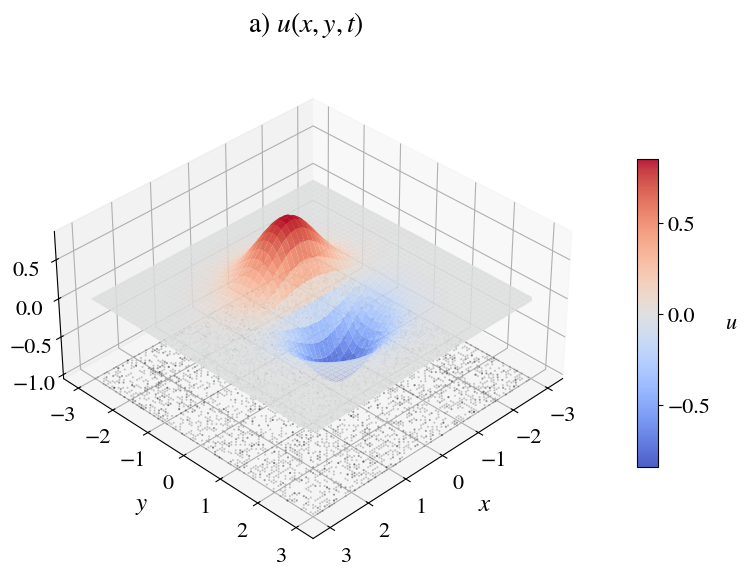

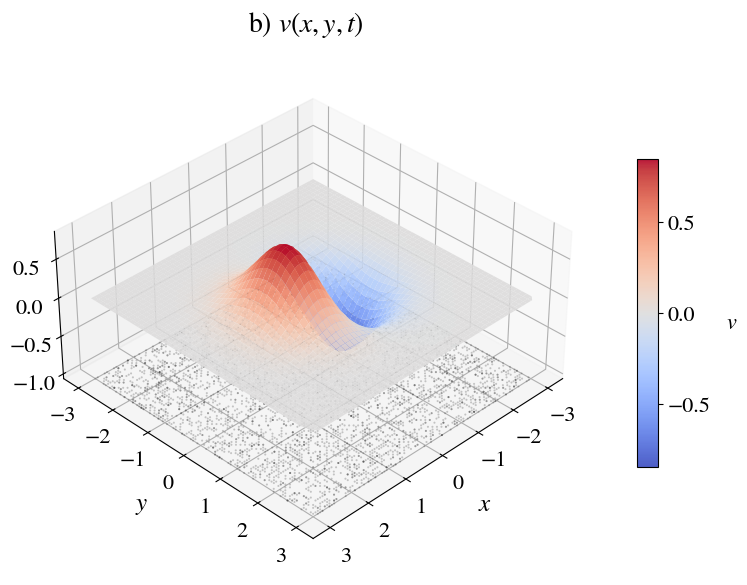

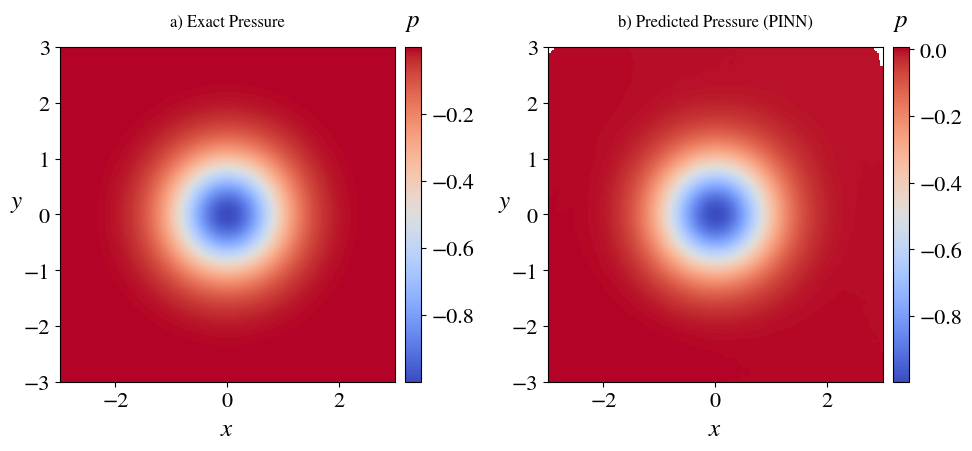

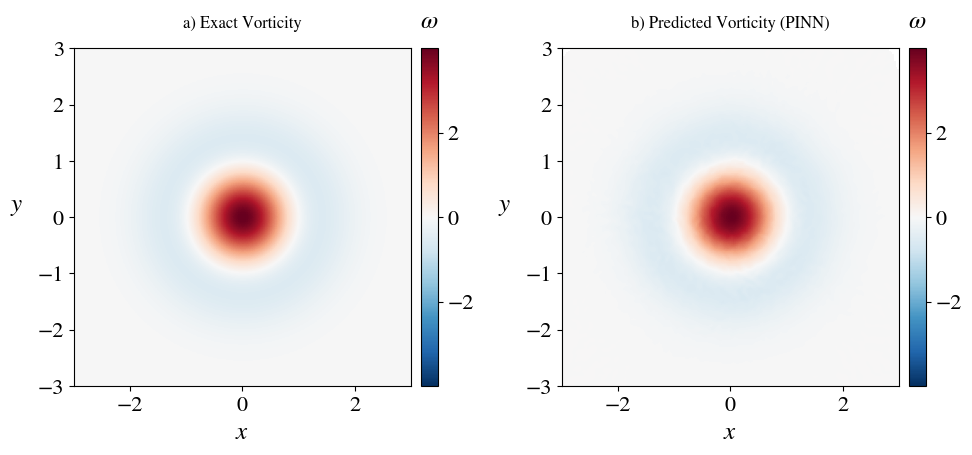

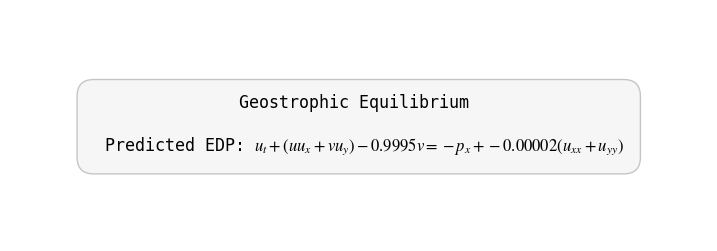

In [7]:
 if __name__ == "__main__": 
     
    # Routes 
    DATA_PATH = '../Data/geostrophic_cyclone_data.mat' 
    RESULTS_PATH = 'Results/Ciclonic/ciclonic_results.npz'
    SAVE_DIR = 'Results/Ciclonic'
    os.makedirs(SAVE_DIR, exist_ok=True)
    
    # Load data
    data = scipy.io.loadmat(DATA_PATH)
    results = np.load(RESULTS_PATH)
    
    X_star = data['X_star'] 
    U_star = data['u_star']
    V_star = data['v_star']
    P_star = data['p_star'] 
    
    u_pred = results['u_pred']
    v_pred = results['v_pred']
    p_pred = results['p_pred']
    snap = int(results['snap'])

    t_star = data['t'].flatten() 
    current_time = t_star[snap]

    print(f"--- SNAPSHOT INFO ---")
    print(f"Snapshot index: {snap}")
    print(f"Physical time (t): {current_time:.4f}")

    # Metrics
    # Define the points where the model made predictions 
    coords_pred = np.hstack([results['x_train'], results['y_train']])
    
    # Define the grid for the exact data 
    x_exact_grid = np.linspace(X_star[:,0].min(), X_star[:,0].max(), 100)
    y_exact_grid = np.linspace(X_star[:,1].min(), X_star[:,1].max(), 100)
    X_grid, Y_grid = np.meshgrid(x_exact_grid, y_exact_grid)
    
    # Interpolate the exact solution (coords_pred)
    u_exact_interp = griddata((X_star[:, 0], X_star[:, 1]), U_star.flatten(), coords_pred, method='cubic')
    v_exact_interp = griddata((X_star[:, 0], X_star[:, 1]), V_star.flatten(), coords_pred, method='cubic')
    p_exact_interp = griddata((X_star[:, 0], X_star[:, 1]), P_star.flatten(), coords_pred, method='cubic')
    
    # Errors
    error_u = np.linalg.norm(u_exact_interp - u_pred.flatten(), 2) / np.linalg.norm(u_exact_interp, 2)
    error_v = np.linalg.norm(v_exact_interp - v_pred.flatten(), 2) / np.linalg.norm(v_exact_interp, 2)
    
    # Pressure centering for relative error calculation
    p_pred_centered = p_pred.flatten() - np.mean(p_pred.flatten())
    p_exact_centered = p_exact_interp - np.mean(p_exact_interp)
    error_p = np.linalg.norm(p_exact_centered - p_pred_centered, 2) / np.linalg.norm(p_exact_centered, 2)
    
    print(f"\n--- PERFORMANCE METRICS ---")
    print(f"Relative L2 (U): {error_u:.4e}")
    print(f"Relative L2 (V): {error_v:.4e}")
    print(f"Relative L2 (P): {error_p:.4e}")
    
    # Min and max values
    p_pred_min, p_pred_max = np.min(p_pred), np.max(p_pred)
    p_exact_min, p_exact_max = np.min(p_exact_interp), np.max(p_exact_interp)
    
    print(f"\n--- PRESSURE RANGES ---")    
    print(f"Predicted Pressure (PINN) | Min: {p_pred_min:.4f}, Max: {p_pred_max:.4f}, Range: {p_pred_max - p_pred_min:.4f}")
    print(f"Exact Pressure            | Min: {p_exact_min:.4f}, Max: {p_exact_max:.4f}, Range: {p_exact_max - p_exact_min:.4f}")

    # Interpolation 
    nn = 200
    x_plot = np.linspace(X_star[:,0].min(), X_star[:,0].max(), nn)
    y_plot = np.linspace(X_star[:,1].min(), X_star[:,1].max(), nn)
    X, Y = np.meshgrid(x_plot, y_plot)
    
    coords_pred = np.hstack([results['x_train'], results['y_train']])
    UU_star = griddata(coords_pred, u_pred.flatten(), (X, Y), method='cubic')
    VV_star = griddata(coords_pred, v_pred.flatten(), (X, Y), method='cubic')
    PP_star = griddata(coords_pred, p_pred.flatten(), (X, Y), method='cubic')

    u_exact = U_star.flatten()
    v_exact = V_star.flatten()
    p_exact = P_star.flatten()
    
    U_exact_grid = griddata(X_star, u_exact, (X, Y), method='cubic')
    V_exact_grid = griddata(X_star, v_exact, (X, Y), method='cubic')
    P_exact_grid = griddata(X_star, p_exact, (X, Y), method='cubic')

    # Plotting velocities (3D)
    plot_3d_surface(X, Y, UU_star, '$u(x,y)$', results['x_train'], results['y_train'],plot_title='a) $u(x,y,t)$').savefig(f'{SAVE_DIR}/Ciclonic_Noisy_U.png', dpi=300, bbox_inches='tight')
    plot_3d_surface(X, Y, VV_star, '$v(x,y)$', results['x_train'], results['y_train'],plot_title='b) $v(x,y,t)$').savefig(f'{SAVE_DIR}/Ciclonic_Noisy_V.png', dpi=300, bbox_inches='tight')  

    # Pressure (2D Plots) 
    fig_p = plt.figure(figsize=(10, 5))
    for i, (data_p, title) in enumerate(zip([P_exact_grid, PP_star], ['a) Exact Pressure', 'b) Predicted Pressure (PINN)'])):
        ax = fig_p.add_subplot(1, 2, i+1)
        h = ax.imshow(data_p, origin='lower', extent=[X_star[:,0].min(), X_star[:,0].max(), X_star[:,1].min(), X_star[:,1].max()], cmap='coolwarm')
        ax.set_title(title, fontsize=12, pad=15)
        ax.set_xlabel('$x$', fontsize=18); ax.set_ylabel('$y$', fontsize=18, rotation=0, labelpad=5)
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        cbar = fig_p.colorbar(h, cax=cax)
        cbar.ax.set_title('$p$', fontsize=18, pad=15)
        
    plt.tight_layout()
    fig_p.savefig(f'{SAVE_DIR}/Ciclonic_Noisy_P.png', dpi=300, bbox_inches='tight')

    # Vorticity (2D Plots)
    dU_dy_pred, dU_dx_pred = np.gradient(UU_star, y_plot, x_plot)
    dV_dy_pred, dV_dx_pred = np.gradient(VV_star, y_plot, x_plot)
    dU_dy_exact, dU_dx_exact = np.gradient(U_exact_grid, y_plot, x_plot)
    dV_dy_exact, dV_dx_exact = np.gradient(V_exact_grid, y_plot, x_plot)

    W_pred = dV_dx_pred - dU_dy_pred
    W_exact = dV_dx_exact - dU_dy_exact
    
    fig_w = plt.figure(figsize=(10, 5))
    vmax = max(np.nanmax(np.abs(W_exact)), np.nanmax(np.abs(W_pred)))
    for i, (data_w, title) in enumerate(zip([W_exact, W_pred], ['a) Exact Vorticity', 'b) Predicted Vorticity (PINN)'])):
        ax = fig_w.add_subplot(1, 2, i+1)
        h = ax.imshow(data_w, origin='lower', extent=[X_star[:,0].min(), X_star[:,0].max(), X_star[:,1].min(), X_star[:,1].max()], cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax.set_title(title, fontsize=12, pad=15)
        ax.set_xlabel('$x$', fontsize=18); ax.set_ylabel('$y$', fontsize=18, rotation=0, labelpad=15)
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        cbar = fig_w.colorbar(h, cax=cax)
        cbar.ax.set_title('$\omega$', fontsize=18, pad=15)
    plt.tight_layout()
    fig_w.savefig(f'{SAVE_DIR}/Ciclonic_Noisy_Vorticity.png', dpi=300, bbox_inches='tight')

    # Discovery Results
    fig_txt = plt.figure(figsize=(9, 3))
    ax_txt = fig_txt.add_subplot(1, 1, 1)
    ax_txt.axis('off')
    txt = (f"Geostrophic Equilibrium \n\n"
           f" Predicted EDP: $u_t + (u u_x + v u_y) - {results['lambda_3']:.4f} v = -p_x + {results['lambda_2']:.5f}(u_{{xx}} + u_{{yy}})$")
    ax_txt.text(0.5, 0.5, txt, fontsize=12, family='monospace', ha='center', va='center',
                bbox=dict(facecolor='whitesmoke', alpha=0.9, edgecolor='silver', boxstyle='round,pad=1'))
    fig_txt.savefig(f'{SAVE_DIR}/Ciclonic_Noisy_Results.png', dpi=300, bbox_inches='tight')
    plt.show()